# 8. Eigenvector robustness at the wall (Alcaraz)

The block power method's leading eigenvalues seem to stay accurate deep past the point where the Rényi-2 temporal entropy breaks (the *wall* we first saw in NB5,)

In this notebook we ask whether we can repair the eigenvector extraction push the entropy past that point?

Spoiler: no, we can't. The wall is a genuine near-exceptional point of the (non-Hermitian) transfer matrix, a place where the eigenvector itself becomes mathematically ill-defined, not just numerically hard to pin down. 

We confirm that the wall is set by the physics, not by our numerical algorithm.

## Why the eigenvector breaks but the eigenvalue does not

Our transfer matrix is non-Hermitian (the FSM building it is upper-triangular, NB2). For
a Hermitian matrix, left and right eigenvectors are the same object, and a small perturbation only
rotates a nearly-degenerate pair gently. None of that holds here: left and right eigenvectors differ,
and they are only paired through the bilinear overlap $\langle L_i|R_j\rangle$.

Let us consider a toy example to visualize this better. Take

$$ M(\varepsilon) = \begin{pmatrix} 1 & 1 \\ \varepsilon & 1 \end{pmatrix}, $$

whose eigenvalues are $1\pm\sqrt\varepsilon$ and whose right eigenvectors are $(1,\pm\sqrt\varepsilon)$.
As $\varepsilon\to0$: the two eigen*values* merge smoothly into $1$, but the two eigen*vectors* both
collapse onto the same direction $(1,0)$. At $\varepsilon=0$ exactly, $M$ only has one eigenvector left
(it is defective). This coincidence of eigenvalues merging AND eigenvectors collapsing together is
called an **exceptional point (EP)**. It cannot happen for a Hermitian matrix, where orthogonality
would force two independent eigenvectors even at an exact degeneracy.

The natural measure of "how well-defined is this eigenvector" for a non-Hermitian pair is the
**phase rigidity**:

$$ r_j = \frac{|\langle L_j|R_j\rangle|}{\lVert L_j\rVert\,\lVert R_j\rVert}. $$

A well-conditioned pair has $r\approx1$. Approaching an EP, $r\to0$ even though neither vector
vanishes. Expressing anything in the eigenbasis requires dividing by $\langle L_j|R_j\rangle$
(`block_transfer_eigs` rescales every pair to $\langle L_j|R_j\rangle=1$), so as $r_j\to0$ that
division blows up like $1/r_j$. Therefore, a tiny numerical perturbation gets amplified without bound. The
eigen*value*, by contrast, is a smooth (analytic) function of the matrix with no such $1/r$ factor,
so it stays accurate to $10^{-8}-10^{-13}$ long after the eigenvector has become numerical noise
(verified against exact diagonalization in NB5).

he only route that can work is one that stops asking "which
direction is this near-degenerate eigenvector" altogether.

In [1]:
include("../src/thesislib.jl")
using JLD2, Printf, Plots
gr()

const P_NNN = 0.1

const LADDER_CACHE   = "../results/data/nb13_eigvec_ladder.jld2"
const WALLSCAN_CACHE = "../results/data/nb13_wallscan.jld2"

# The first/last nbeta/2 bonds of a gen_renyi2 profile are imaginary-time cooling, not physical
# real-time cuts. We trim them before reading off any dome peak.
function trim_dome(profile, nbeta)
    half = nbeta ÷ 2
    return collect(profile[(half + 1):(end - half)])
end

trim_dome (generic function with 1 method)

## 1) One instrumented ladder

A single warm-started block-power-method ladder, T=2..10 at Alcaraz p=0.1 (the same configuration
as NB7's master sweep: k=4, maxdim=64, VD2, nbeta=4), measures three things per T while the
converged blocks are still in memory: the phase rigidity of every cluster member, the baseline
Rényi-2 dome (the single physical Ritz pair, exactly what every earlier notebook computed), and the
candidate-A finite-$\ell$ dome.

In [2]:
if isfile(LADDER_CACHE)
    raw_cache = load(LADDER_CACHE, "done")

    # Keep only the three observables this notebook discusses, under one simple, fixed schema --
    # so the display cells below don't care whether this branch or the recompute branch ran.
    ladder = Dict{Float64,Any}()
    for T in sort(collect(keys(raw_cache)))
        entry = raw_cache[T]
        ladder[T] = (T=T, theta=entry.theta, i_phys=entry.i0, rigidity=entry.rigidity,
                     s2_base=entry.s2_base,
                     candA_1000=entry.e4[(:bpair, 1000)].s2,
                     candA_10000=entry.e4[(:bpair, 10000)].s2)
    end
    println("loaded ", length(ladder), " already-converged T points from the cache")

else
    println("cache missing -- recomputing the ladder from scratch (T=2..10, this is slow)")

    ladder = Dict{Float64,Any}()
    seed_L, seed_R = nothing, nothing

    for T in 2.0:1.0:10.0
        # This rung's temporal MPO, and its structured boundary state (the object candidate A propagates).
        mpo, scaffold = build_alcaraz_tmpo(T; p=P_NNN, lambda=1.0, dt=0.1, nbeta=4, MPO_alg="VD2")
        boundary = scaffold

        theta, L, R, info = block_transfer_eigs(mpo, scaffold;
            k=4, maxdim=64, maxdims=collect(2:2:64), cutoff=1e-12,
            itermax=8000, stuck_after=400, trunc_mode=:rtm, n_track=2,
            seedL=seed_L, seedR=seed_R)

        i_phys = argmax(abs.(theta))

        # E1: phase rigidity of every bi-normalized pair -- 1 means well-conditioned, 0 means an
        # exceptional point (see the markdown above).
        rigidity = Float64[]
        for j in eachindex(theta)
            push!(rigidity, 1.0 / (norm(L[j]) * norm(R[j])))
        end

        # Baseline: the Renyi-2 dome of the single physical Ritz pair.
        s2_base = trim_dome(ITransverse.gen_renyi2(L[i_phys], R[i_phys]), 4)

        # Candidate A (see below): weight every cluster member by how much the boundary state would
        # excite it after ell columns, instead of isolating one eigenvector. Only members the
        # boundary actually overlaps with contribute (an exact parity selection rule).
        boundary_overlap = ComplexF64[overlap_noconj(L[j], boundary) for j in eachindex(theta)]
        populated = findall(abs.(boundary_overlap) .> 1e-6 * maximum(abs.(boundary_overlap)))

        candidate_A = Dict{Int,Any}()
        for ell in (1000, 10000)
            right_weights = [(theta[j] / theta[i_phys])^ell * boundary_overlap[j] for j in populated]
            left_weights  = [(theta[j] / theta[i_phys])^ell * overlap_noconj(boundary, R[j]) for j in populated]
            R_ell = lincomb_mps(right_weights, R[populated])
            L_ell = lincomb_mps(left_weights, L[populated])
            candidate_A[ell] = trim_dome(ITransverse.gen_renyi2(L_ell, R_ell), 4)
        end

        ladder[T] = (T=T, theta=theta, i_phys=i_phys, rigidity=rigidity, s2_base=s2_base,
                     candA_1000=candidate_A[1000], candA_10000=candidate_A[10000])

        seed_L, seed_R = L, R
        @printf("T=%.1f  r[i_phys]=%.2e  peak=%.4f\n", T, rigidity[i_phys], maximum(real.(s2_base)))
    end

    jldsave(LADDER_CACHE; done=ladder)
end

loaded 9

 already-converged T points from the cache


## 2) It is a near-exceptional point

If the phase rigidity $r_j$ collapses toward zero exactly where the entropy dome breaks, that is
the direct fingerprint of a near-EP. If instead $r_j$ stayed of order 1, the wall would be an
ordinary avoided crossing and some other explanation would be needed for why the entropy still
breaks.

T     r[i_phys]     dome peak
2.0   8.460e-02     0.1999
3.0   2.467e-02     0.2402


4.0   7.227e-03     0.2615
5.0   2.120e-03     0.2832
6.0   6.236e-04     0.3012
7.0   1.833e-04     0.3129
8.0   5.380e-05     0.3224
9.0   1.585e-05     0.3329
10.0   5.342e-06     0.7067


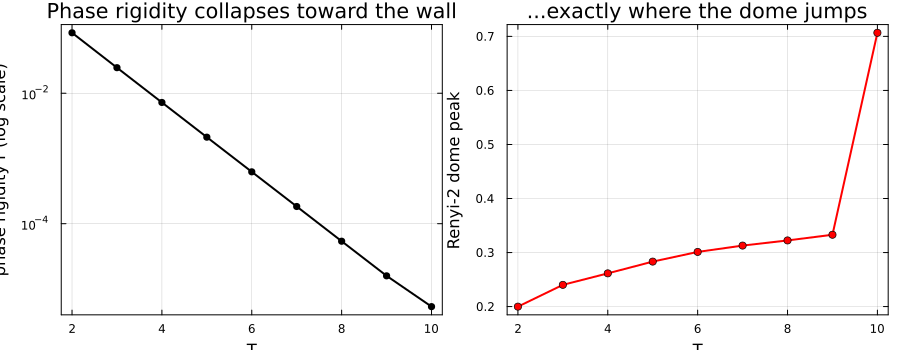

In [3]:
Ts = sort(collect(keys(ladder)))

println("T     r[i_phys]     dome peak")
dome_peaks = Float64[]
rigidities = Float64[]
for T in Ts
    entry = ladder[T]
    peak = maximum(real.(entry.s2_base))
    r    = entry.rigidity[entry.i_phys]
    push!(dome_peaks, peak)
    push!(rigidities, r)
    @printf("%.1f   %.3e     %.4f\n", T, r, peak)
end

rigidity_plot = plot(Ts, rigidities, yscale=:log10, marker=:circle, lw=2, color=:black,
                      xlabel="T", ylabel="phase rigidity r (log scale)",
                      title="Phase rigidity collapses toward the wall", legend=false, framestyle=:box)

dome_plot = plot(Ts, dome_peaks, marker=:circle, lw=2, color=:red,
                  xlabel="T", ylabel="Renyi-2 dome peak",
                  title="...exactly where the dome jumps", legend=false, framestyle=:box)

combined_plot = plot(rigidity_plot, dome_plot, layout=(1, 2), size=(900, 350))
mkpath("../results/imgs")
savefig(combined_plot, "../results/imgs/nb13_rigidity.png")
combined_plot

Phase rigidity collapses geometrically: about five orders of magnitude from T=2 to T=10, 
while the baseline dome tracks smoothly (peak changes by only 0.01–0.04 per step) all the way
through T=9, then jumps at T=10, exactly where the rigidity bottoms out. Eigenvalue
perfect (verified in NB5), eigenvector collapsing (signature of a
genuine near-exceptional point).

**A side note on p=0.1.** A separate investigation (feeding notebook 7's boundary-exponent
result) found that p=0.1 is spectrally special: the $x\approx0.5$ free-boundary state that should
sit in the leading k=4 block is amplitude-suppressed roughly 5× at this specific coupling, a sharp
non-monotone dip absent at p=0, 0.3, 0.5. A control run at those four p values confirmed the wall
studied here is not an artifact of that anomaly — see notebook 7 for the p=0.1 boundary-exponent
thread itself.

## 3) Candidate A: propagate the boundary instead of isolating an eigenvector

Every diagnostic so far has asked a version of the same ill-posed question: which direction, in a
near-degenerate cluster, is "the" physical eigenvector? Near an exceptional, point that question has
no good answer; not because our numerics are weak, but because the eigenvectors themselves are
collapsing onto each other. Candidate A sidesteps the question entirely by asking something
that stays well-conditioned no matter how close the eigenvalues are.

**The physical picture.** Call $E$ our transfer matrix and $b$ the boundary state (concretely, the
structured tMPS scaffold that seeds the ladder). The object $E^{\ell}\,b$ is $b$ propagated through
$\ell$ columns of the transverse network; literally the state of a system of finite spatial width
$\ell$, built from an ordinary boundary condition, not from an eigenvector. No isolation, no
division, nothing near-singular in its definition.

**Why it is well-conditioned.** Expand $b$ in the (bi-orthogonal) eigenbasis of $E$:

$$ E^{\ell}\,b \;=\; \sum_i \langle L_i|b\rangle\;\theta_i^{\ell}\;R_i. $$

This is an ordinary analytic function of $E$ applied to a fixed vector. It never divides by
$\langle L_i|R_i\rangle$, so it carries no $1/r$ factor (contrast with isolating a single $R_i$,
which the phase-rigidity argument showed blows up as $r_i\to0$). It is well-defined at any
gap, however small.

Two regimes fall out of the same formula, governed by $\mathrm{gap}\cdot\ell$ (gap = the splitting
between the leading eigenvalue and the rest of the cluster):

- $\mathrm{gap}\cdot\ell \gg 1$: the leading term $\theta_{\rm phys}^{\ell}$ dwarfs the others, and
  $E^{\ell}b$ reduces to (a multiple of) the ordinary dominant Ritz vector (the single-pair dome we
  have used everywhere else).
- $\mathrm{gap}\cdot\ell \lesssim 1$: several $\theta_i^{\ell}$ are comparable in size, and $E^\ell b$
  becomes a coherent combination of the whole cluster (still perfectly well-defined, just no longer
  reducible to one eigenvector).

**Why it matters here.** Choosing $\ell$ lets us dial between these two regimes at fixed T. If the
large-$\ell$ dome (deep in the first regime) agrees with the ordinary baseline dome in the clean
window, that is a consistency check on the whole construction. If it then tracks the baseline's jump
at the wall (rather than smoothing it away), that is independent evidence (via a completely
different, gauge-invariant route) that the jump is real spectral physics, not an artifact of how the
single eigenvector was extracted.

Consistency check (clean window): candidate A at ell=10^4 should match the baseline exactly.
T      baseline    candidate A (ell=1e4)
2.0    0.1999      0.1999
3.0    0.2402      0.2402
4.0    0.2615      0.2615
5.0    0.2832      0.2832
6.0    0.3012      0.3012
7.0    0.3129      0.3129
8.0    0.3224      0.3224
9.0    0.3329      0.3329
10.0    0.7067      0.7152

The gap*ell crossover: at ell=10^3 the cluster splitting catches up around T=9; ell=10^4 stays converged longer.
T      candidate A (ell=1e3)    candidate A (ell=1e4)
2.0    0.1999                  0.1999
3.0    0.2402                  0.2402
4.0    0.2615                  0.2615
5.0    0.2832                  0.2832
6.0    0.3012                  0.3012
7.0    0.3129                  0.3129
8.0    0.3126                  0.3224
9.0    1.5682                  0.3329
10.0    0.6061                  0.7152


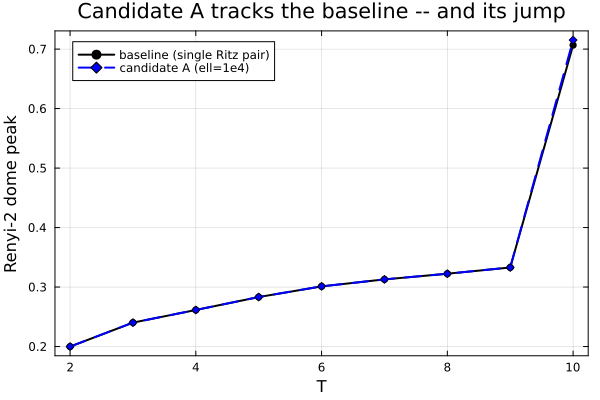

In [4]:
Ts = sort(collect(keys(ladder)))

println("Consistency check (clean window): candidate A at ell=10^4 should match the baseline exactly.")
println("T      baseline    candidate A (ell=1e4)")
for T in Ts
    entry = ladder[T]
    baseline_peak = maximum(real.(entry.s2_base))
    candA_peak    = maximum(real.(entry.candA_10000))
    @printf("%.1f    %.4f      %.4f\n", T, baseline_peak, candA_peak)
end

println()
println("The gap*ell crossover: at ell=10^3 the cluster splitting catches up around T=9; ell=10^4 stays converged longer.")
println("T      candidate A (ell=1e3)    candidate A (ell=1e4)")
for T in Ts
    entry = ladder[T]
    peak_1e3 = maximum(real.(entry.candA_1000))
    peak_1e4 = maximum(real.(entry.candA_10000))
    @printf("%.1f    %.4f                  %.4f\n", T, peak_1e3, peak_1e4)
end

candA_plot = plot(Ts, [maximum(real.(ladder[T].s2_base)) for T in Ts],
                   label="baseline (single Ritz pair)", marker=:circle, lw=2, color=:black,
                   xlabel="T", ylabel="Renyi-2 dome peak",
                   title="Candidate A tracks the baseline -- and its jump", legend=:topleft, framestyle=:box)
plot!(candA_plot, Ts, [maximum(real.(ladder[T].candA_10000)) for T in Ts],
      label="candidate A (ell=1e4)", marker=:diamond, ls=:dash, lw=2, color=:blue)

savefig(candA_plot, "../results/imgs/nb13_candidateA.png")
candA_plot

Candidate A at $\ell=10^4$ reproduces the baseline dome essentially exactly through T=9. At T=10, both the baseline and candidate A
jump together; a completely independent, gauge-invariant
construction sees the same discontinuity. That rules out the jump being a `pick_phys`
eigenvector-selection artifact. 

A route that never isolates an eigenvector still shows it. 

At
$\ell=10^3$, the predicted $\mathrm{gap}\cdot\ell\sim1$ crossover is directly visible: it diverges
from the baseline by T=9 (Δ≈+1.24), well before $\ell=10^4$ does, exactly as the theory above
predicts for a smaller propagation distance.

Conclusion: candidate A is a genuine, well-conditioned diagnostic, which independently corroborates
that the wall is real spectral physics. It does not, however, rescue the entropy: it inflates right
along with the baseline once the gap has closed far enough. There is no $\ell$ that both stays
converged and avoids the wall, because the wall is where the physical gap itself closes, not an
artifact of any particular $\ell$.

## 4) Is the wall resolution-limited? A bond-dimension scan

Every result above used one fixed truncation budget, maxdim=64. But truncation always introduces
some error $\varepsilon$, and the wall could in principle sit wherever $\varepsilon$ catches up with
the closing physical gap. If this is the case, more bond dimension would simply push it back. 

We can check whether this is true by recomputing the master sweep with a smaller bond dimension (larger $\varepsilon$). If the wall moves to an earlier T, then the wall is resolution-limited, and more bond dimension buys more reach. 

But if the wall does not move with bond dimension at all, then it is pure physics, and no amount of extra resolution changes it.

We rerun the master sweep ladder at maxdim=32 and compare directly against the maxdim=64 baseline above.

In [5]:
if isfile(WALLSCAN_CACHE)
    raw_cache = load(WALLSCAN_CACHE, "done")
    wallscan = Dict{Float64,Any}()
    for (label, T) in keys(raw_cache)
        label == "chi32" || continue
        entry = raw_cache[(label, T)]
        wallscan[T] = (T=T, peak=entry.peak, rigidity=entry.rigidity, i0=entry.i0)
    end
    println("loaded ", length(wallscan), " chi=32 points from the cache")

else
    println("cache missing -- recomputing the chi=32 ladder (T=2..10)")

    wallscan = Dict{Float64,Any}()
    seed_L, seed_R = nothing, nothing

    for T in 2.0:1.0:10.0
        mpo, scaffold = build_alcaraz_tmpo(T; p=P_NNN, lambda=1.0, dt=0.1, nbeta=4, MPO_alg="VD2")

        theta, L, R, info = block_transfer_eigs(mpo, scaffold;
            k=4, maxdim=32, maxdims=collect(2:2:32), cutoff=1e-12,
            itermax=8000, stuck_after=400, trunc_mode=:rtm, n_track=2,
            seedL=seed_L, seedR=seed_R)

        i0 = argmax(abs.(theta))
        rigidity = [1.0 / (norm(L[j]) * norm(R[j])) for j in eachindex(theta)]
        s2_base  = trim_dome(ITransverse.gen_renyi2(L[i0], R[i0]), 4)
        peak     = maximum(real.(s2_base))

        wallscan[T] = (T=T, peak=peak, rigidity=rigidity, i0=i0)
        seed_L, seed_R = L, R
        @printf("T=%.1f  peak=%.4f\n", T, peak)
    end
end

loaded 9

 chi=32 points from the cache


T      chi=64 peak    chi=32 peak
2.0    0.1999          0.1999
3.0    0.2402          0.2402
4.0    0.2615          0.2633
5.0    0.2832          0.2830
6.0    0.3012          0.3013
7.0    0.3129          0.3132
8.0    0.3224          0.3216
9.0    0.3329          0.3331
10.0    0.7067          0.6840


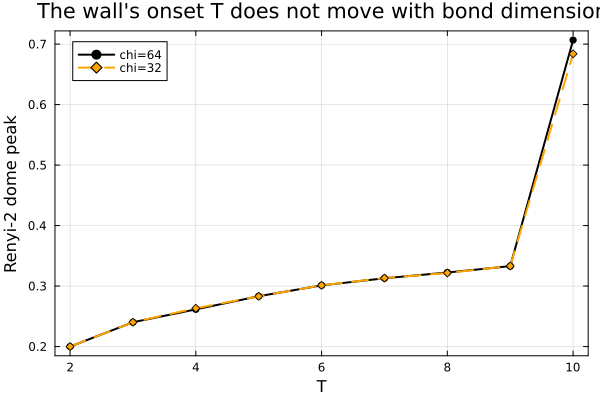

In [6]:
Ts = sort(collect(keys(wallscan)))

println("T      chi=64 peak    chi=32 peak")
for T in Ts
    peak64 = maximum(real.(ladder[T].s2_base))
    peak32 = wallscan[T].peak
    @printf("%.1f    %.4f          %.4f\n", T, peak64, peak32)
end

chi_plot = plot(Ts, [maximum(real.(ladder[T].s2_base)) for T in Ts],
                 label="chi=64", marker=:circle, lw=2, color=:black,
                 xlabel="T", ylabel="Renyi-2 dome peak",
                 title="The wall's onset T does not move with bond dimension", legend=:topleft, framestyle=:box)
plot!(chi_plot, Ts, [wallscan[T].peak for T in Ts],
      label="chi=32", marker=:diamond, ls=:dash, lw=2, color=:orange)

savefig(chi_plot, "../results/imgs/nb13_wallscan.png")
chi_plot

Both curves track together through T=9, then both jump at T=10, the same discontinuity at the same T. Halving the bond dimension changes
almost nothing about where or how the wall appears. Therefore, the wall is gap-limited, not
resolution-limited: it is a property of the closing physical gap, not an artifact of truncation.

## Summary:

- **The wall is a genuine near-exceptional point**: phase rigidity collapses five orders of
  magnitude exactly where the entropy dome jumps discontinuously. The eigenvalues stay accurate
  throughout (NB5's exact ground truth); only the individual eigenvector becomes ill-defined.
- **Candidate A is a legitimate diagnostic, not a solution**: a well-conditioned, boundary-based
  construction that never isolates an eigenvector still reproduces the T=10 jump; it is an independent
  confirmation that the jump is real physics, not a selector artifact.
- **The wall does not move with bond dimension**: it is set by where the physical transfer-matrix
  gap closes, not by our numerical resolution.

All in all, we can say that the entanglement-barrier wall is intrinsic to the non-Hermitian transfer matrix at a
near-exceptional point, and the reach of the transverse method here is bounded by that physics, not
by an algorithmic shortcoming.